# **Part 05**
# **Coupled Finite Element Simulation of Hydrogen and Hydroxide Ion Transport**

## **Objective**

In this part, the single-species diffusion model developed in Parts 1–4 is extended to a coupled two-species reaction–diffusion model.

The two transported species are:

* hydrogen ions, represented by $c_{\mathrm{H}^+}$;
* hydroxide ions, represented by $c_{\mathrm{OH}^-}$.

Both ionic species diffuse through the two-dimensional domain at different rates. When hydrogen and hydroxide ions meet, they undergo a neutralization reaction. Therefore, their concentrations depend on both diffusion and chemical reaction.

The model used in this part is dimensionless. Physical units, electrode fluxes, and pH calculations will be introduced in the next stage.

---

## **Motivation for the Coupled Ion-Transport Model**

Parts 1 through 4 were about the diffusion of one concentration. But electrochemical and biological systems often involve many interacting species.

Diffusion coefficients of hydrogen and hydroxide ions are different and they react when concentration distributions overlap. Thus a single diffusion equation cannot describe their coupled behavior.

Part 5 is required to:

1. extend the validated FEM solver from one to two species;
2. introduce different diffusion coefficients;
3. have a non-linear neutralization reaction;
4. simulate interaction of hydrogen and hydroxide ions;
5. Find the area of the highest reaction;
6. check important conservation and positivity properties;
7. prepare the model for electrode fluxes and pH evolution.

---
## **Computational Domain**

The simulation is performed on the unit-square domain

$$
\Omega=[0,1]\times[0,1].
$$

The domain is divided using

$$
N_x=N_y=12
$$

subdivisions.

Therefore, the number of nodes is

$$
N_{\mathrm{nodes}}
=
(N_x+1)(N_y+1)
=
169,
$$

and the number of triangular elements is

$$
N_{\mathrm{elements}}
=
2N_xN_y
=
288.
$$

---

## **Coupled Governing Equations**

The hydrogen-ion concentration satisfies

$$
\frac{\partial c_{\mathrm{H}^+}}{\partial t}
=
D_{\mathrm{H}^+}\nabla^2c_{\mathrm{H}^+}
-
R(c_{\mathrm{H}^+},c_{\mathrm{OH}^-}).
$$

The hydroxide-ion concentration satisfies

$$
\frac{\partial c_{\mathrm{OH}^-}}{\partial t}
=
D_{\mathrm{OH}^-}\nabla^2c_{\mathrm{OH}^-}
-
R(c_{\mathrm{H}^+},c_{\mathrm{OH}^-}).
$$

Here:

* $c_{\mathrm{H}^+}$ is the dimensionless hydrogen-ion concentration;
* $c_{\mathrm{OH}^-}$ is the dimensionless hydroxide-ion concentration;
* $D_{\mathrm{H}^+}$ is the hydrogen-ion diffusion coefficient;
* $D_{\mathrm{OH}^-}$ is the hydroxide-ion diffusion coefficient;
* $R$ is the neutralization reaction rate;
* $\nabla^2$ is the two-dimensional Laplacian.

The code uses

$$
D_{\mathrm{H}^+}=0.03
$$

and

$$
D_{\mathrm{OH}^-}=0.02.
$$

Because

$$
D_{\mathrm{H}^+}>D_{\mathrm{OH}^-},
$$

hydrogen ions diffuse faster than hydroxide ions in this dimensionless model.

---

## **Neutralization Reaction**

The nonlinear reaction term is defined as

$$
R(c_{\mathrm{H}^+},c_{\mathrm{OH}^-})
=
k\,c_{\mathrm{H}^+}c_{\mathrm{OH}^-},
$$

where $k$ is the dimensionless reaction-rate constant.

The code uses

$$
k=8.
$$

The reaction term is large where both concentrations are large. It becomes small when either hydrogen or hydroxide concentration is small.

Because the same reaction term is subtracted from both equations, hydrogen and hydroxide ions are consumed in equal amounts:

$$
\mathrm{H}^+ + \mathrm{OH}^-
\longrightarrow
\mathrm{H_2O}.
$$

---

## **Boundary Conditions**

Zero-flux boundary conditions are applied to both ionic species:

$$
-D_{\mathrm{H}^+}
\frac{\partial c_{\mathrm{H}^+}}{\partial n}
=
0
\qquad
\text{on } \partial\Omega,
$$

and

$$
-D_{\mathrm{OH}^-}
\frac{\partial c_{\mathrm{OH}^-}}{\partial n}
=
0
\qquad
\text{on } \partial\Omega.
$$

These conditions mean that neither hydrogen nor hydroxide ions enter or leave through the outer boundary.

The zero-flux conditions are naturally included in the finite element weak formulation. Therefore, no additional boundary terms are added to the code.

---

## **Initial Hydrogen-Ion Concentration**

The initial hydrogen concentration is a Gaussian distribution centred near the left side of the domain:

$$
c_{\mathrm{H}^+}(x,y,0)
=
0.05
+
\exp
\left[
-\frac{
(x-0.30)^2+(y-0.50)^2
}{
2\sigma^2
}
\right].
$$

The code uses

$$
\sigma=0.14.
$$

The constant value $0.05$ provides a small background concentration throughout the domain.

---

## **Initial Hydroxide-Ion Concentration**

The initial hydroxide concentration is centred near the right side of the domain:

$$
c_{\mathrm{OH}^-}(x,y,0)
=
0.05
+
0.80
\exp
\left[
-\frac{
(x-0.70)^2+(y-0.50)^2
}{
2\sigma^2
}
\right].
$$

The factor $0.80$ makes the initial hydroxide peak smaller than the hydrogen peak.

The two initial peaks are placed on opposite sides so that they diffuse towards each other and create a reaction zone in the central part of the domain.

---

## **Triangular-Element Area**

For a triangular element with vertices

$$
(x_1,y_1),\qquad
(x_2,y_2),\qquad
(x_3,y_3),
$$

the signed area is calculated using

$$
A_e
=
\frac{1}{2}
\left[
(x_2-x_1)(y_3-y_1)
-
(x_3-x_1)(y_2-y_1)
\right].
$$

The code verifies that

$$
A_e>0
$$

for every element.

This confirms that all triangular elements have counter-clockwise node orientation and that no element is degenerate.

---

## **Basis-Function Gradients**

For every triangular element, the coefficients are

$$
b_1=y_2-y_3,
\qquad
b_2=y_3-y_1,
\qquad
b_3=y_1-y_2,
$$

and

$$
d_1=x_3-x_2,
\qquad
d_2=x_1-x_3,
\qquad
d_3=x_2-x_1.
$$

The basis-function gradients are

$$
\nabla\phi_i
=
\frac{1}{2A_e}
\begin{bmatrix}
b_i\\
d_i
\end{bmatrix}.
$$

In the Python code, the coefficients $d_i$ are stored in the variable `c_coefficients`.

---

## **Local Mass Matrix**

The local mass matrix for a linear triangular element is

$$
M^{(e)}
=
\frac{A_e}{12}
\begin{bmatrix}
2&1&1\\
1&2&1\\
1&1&2
\end{bmatrix}.
$$

The global mass matrix is obtained by assembling all local mass matrices:

$$
M
=
\sum_e M^{(e)}.
$$

---

## **Local Stiffness Matrix**

In this part, the code first constructs a unit-diffusion local stiffness matrix:

$$
K_0^{(e)}
=
A_eGG^T,
$$

where $G$ contains the gradients of the three basis functions.

The global unit-diffusion stiffness matrix is

$$
K_0
=
\sum_e K_0^{(e)}.
$$

The two diffusion coefficients are applied separately during time integration:

$$
K_{\mathrm{H}^+}
=
D_{\mathrm{H}^+}K_0,
$$

and

$$
K_{\mathrm{OH}^-}
=
D_{\mathrm{OH}^-}K_0.
$$

This allows the two ionic species to have different diffusion rates while using the same mesh and basis functions.

---

## **Semi-Discrete FEM System**

Let

$$
\mathbf{h}(t)
$$

represent the nodal hydrogen concentrations and

$$
\mathbf{o}(t)
$$

represent the nodal hydroxide concentrations.

The semi-discrete hydrogen equation is

$$
M\frac{d\mathbf{h}}{dt}
+
D_{\mathrm{H}^+}K_0\mathbf{h}
+
M\mathbf{r}(\mathbf{h},\mathbf{o})
=
\mathbf{0}.
$$

The semi-discrete hydroxide equation is

$$
M\frac{d\mathbf{o}}{dt}
+
D_{\mathrm{OH}^-}K_0\mathbf{o}
+
M\mathbf{r}(\mathbf{h},\mathbf{o})
=
\mathbf{0}.
$$

The nodal reaction vector is

$$
\mathbf{r}(\mathbf{h},\mathbf{o})
=
k(\mathbf{h}\odot\mathbf{o}),
$$

where $\odot$ represents component-wise multiplication.

---

## **IMEX Euler Time Integration**

A first-order implicit-explicit Euler method is used.

The diffusion terms are treated implicitly because implicit diffusion is numerically stable. The nonlinear reaction term is treated explicitly to avoid solving a nonlinear system at every time step.

For hydrogen ions:

$$
\left(
M+
\Delta tD_{\mathrm{H}^+}K_0
\right)
\mathbf{h}^{n+1}
=
M\mathbf{h}^{n}
-
\Delta tM\mathbf{r}^{n}.
$$

For hydroxide ions:

$$
\left(
M+
\Delta tD_{\mathrm{OH}^-}K_0
\right)
\mathbf{o}^{n+1}
=
M\mathbf{o}^{n}
-
\Delta tM\mathbf{r}^{n}.
$$

The reaction vector at the current time level is

$$
\mathbf{r}^{n}
=
k\left(
\mathbf{h}^{n}
\odot
\mathbf{o}^{n}
\right).
$$

The code uses

$$
\Delta t=0.0005
$$

and

$$
T=0.20.
$$

Therefore, the number of time steps is

$$
N_t
=
\frac{T}{\Delta t}
=
400.
$$

A small time step is used because the reaction term is treated explicitly.

---

## **Linear System Matrices**

The hydrogen system matrix is

$$
A_{\mathrm{H}^+}
=
M+
\Delta tD_{\mathrm{H}^+}K_0.
$$

The hydroxide system matrix is

$$
A_{\mathrm{OH}^-}
=
M+
\Delta tD_{\mathrm{OH}^-}K_0.
$$

Because these matrices do not change during the simulation, each matrix is factorized only once using LU factorization.

At every time step, the stored LU factors are reused to solve the two linear systems efficiently.

---

## **Total Ion Concentrations**

The total hydrogen concentration is approximated by

$$
C_{\mathrm{H}^+}(t)
=
\mathbf{1}^{T}M\mathbf{h}(t),
$$

where $\mathbf{1}$ is a vector containing ones.

Similarly, the total hydroxide concentration is

$$
C_{\mathrm{OH}^-}(t)
=
\mathbf{1}^{T}M\mathbf{o}(t).
$$

Because the neutralization reaction consumes both species, both total concentrations should decrease with time.

---

## **Conservation of the Mass Difference**

The concentration difference is defined as

$$
\Delta C(t)
=
C_{\mathrm{H}^+}(t)
-
C_{\mathrm{OH}^-}(t).
$$

The same reaction term is subtracted from both governing equations. Therefore, the reaction cancels when the two equations are subtracted.

Under zero-flux boundary conditions,

$$
\frac{d}{dt}
\left[
C_{\mathrm{H}^+}(t)
-
C_{\mathrm{OH}^-}(t)
\right]
=
0.
$$

Therefore,

$$
\Delta C(t)
=
\Delta C(0).
$$

The numerical conservation error is calculated using

$$
E_{\mathrm{difference}}
=
\max_n
\left|
\Delta C^n-\Delta C^0
\right|.
$$

A value close to zero confirms that the coupled reaction has been implemented consistently.

---

## **Integrated Rate of Reaction**

The reaction rate over the complete domain is approximated by

$$
R_{\mathrm{total}}(t)
=
\mathbf{1}^{T}
M
\mathbf{r}(t).
$$

This value measures the total neutralization activity occurring inside the domain at a particular time.

---

## **Numerical Verification**

This code checks the following properties:

1. Total mesh area = area of the domain.
2. All triangular elements have positive area.
3. The mass matrix of the world is symmetric.
4. The global stiffness matrix is symmetrical.
5. All calculated concentrations must be finite.
6. No significant negative concentration is created.
7. Keeps total hydrogen concentration from increasing.
8. No increase in total hydroxide concentration.
9. The mass difference of hydrogen and hydroxide is maintained.
10. Both species have a maximum concentration that decreases with time.

The concentration-positivity test is

$$
\min
\left(
c_{\mathrm{H}^+},
c_{\mathrm{OH}^-}
\right)
\geq
-10^{-10}.
$$

The small negative tolerance allows for possible floating-point round-off errors.

---

## **Visualization**

This code generates three figures.

### **Ion-Concentration Evolution**

Hydrogen and hydroxide concentration distributions are plotted at

$$
t=0,\quad0.05,\quad0.10,\quad0.20.
$$

These plots show the diffusion and neutralization of both ionic species.

### **Neutralization-Reaction Evolution**

The reaction rate

$$
R
=
k\,c_{\mathrm{H}^+}c_{\mathrm{OH}^-}
$$

is plotted at the selected times.

These plots identify the region where hydrogen and hydroxide ions overlap and react most strongly.

### **Numerical Verification Graphs**

The final figure displays:

* maximum hydrogen and hydroxide concentrations;
* total hydrogen and hydroxide concentrations;
* mass-difference conservation error;
* integrated neutralization rate.
---



Number of nodes: 169
Number of elements: 288
Hydrogen-ion diffusion coefficient: 0.03
Hydroxide-ion diffusion coefficient: 0.02
Reaction-rate constant: 8.0
Global FEM matrices assembled successfully.
Mass matrix shape: (169, 169)
Stiffness matrix shape: (169, 169)
Total mesh area: 1.0
Initial time: 0.0
Final time: 0.2
Time-step size: 0.0005
Number of time steps: 400
Coupled ion-transport simulation completed.
Initial total hydrogen concentration: 0.17080323403902556
Final total hydrogen concentration: 0.1470494604883069
Initial total hydroxide concentration: 0.14664258723122042
Final total hydroxide concentration: 0.12288881368050206
Initial mass difference: 0.024160646807805136
Final mass difference: 0.02416064680780483
Maximum mass-difference error: 3.469446951953614e-16
Minimum concentration during simulation: 0.02285504728105274
Initial maximum hydrogen concentration: 1.022053270286608
Final maximum hydrogen concentration: 0.5864267779019009
Initial maximum hydroxide concentration:

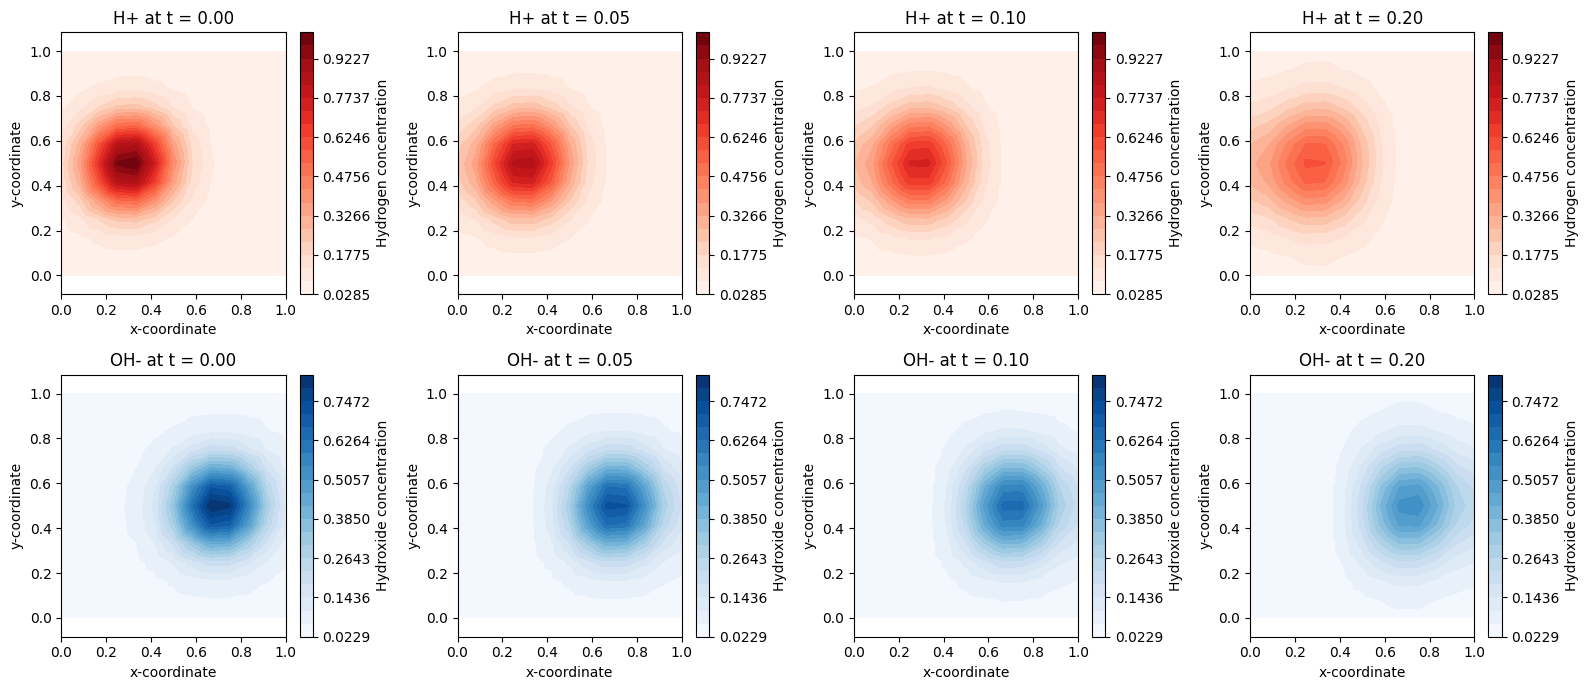

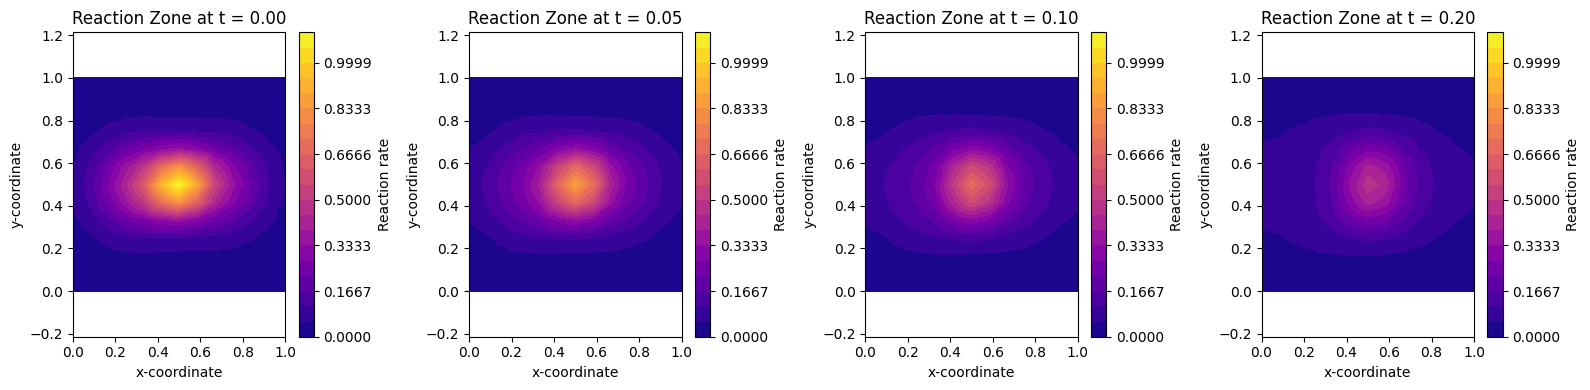

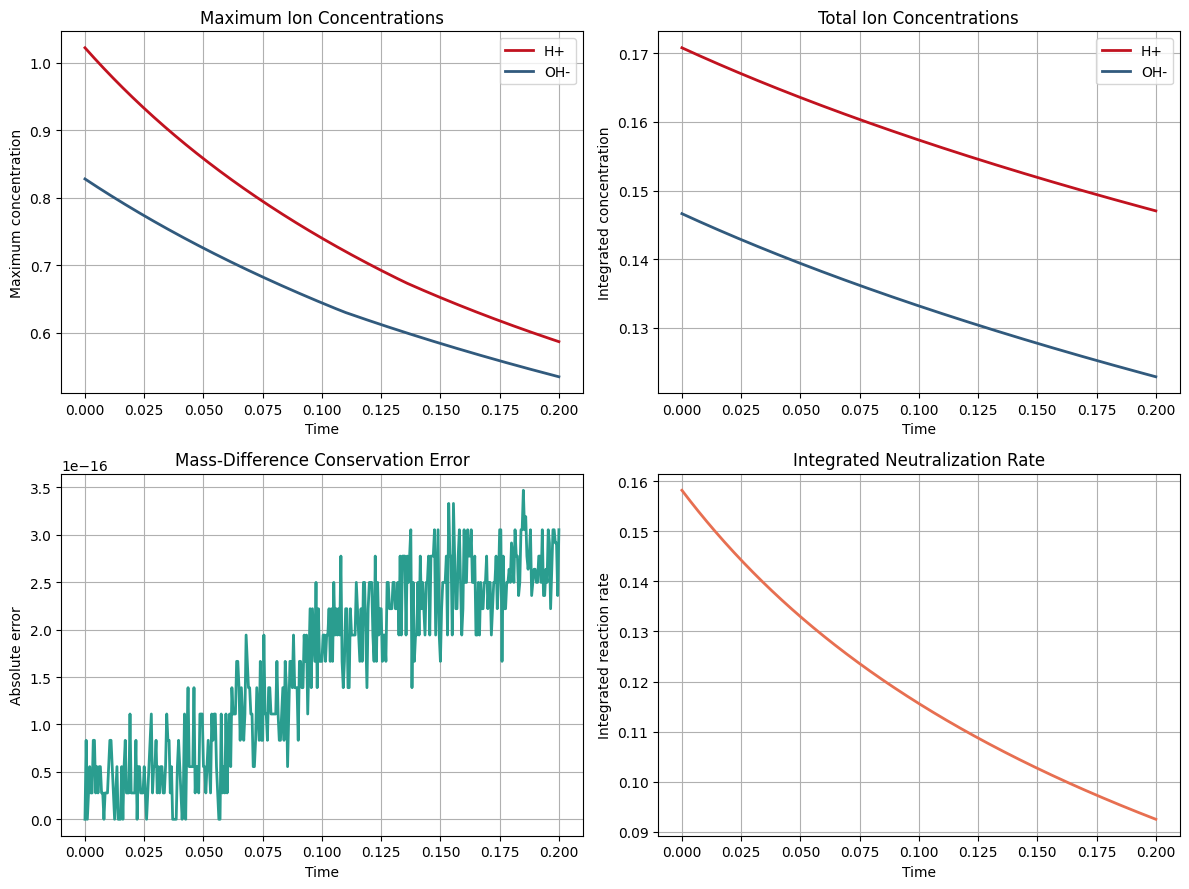

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
np.set_printoptions(precision=8, suppress=True)
Lx = 1.0
Ly = 1.0
Nx = 12
Ny = 12
x = np.linspace(0.0, Lx, Nx + 1)
y = np.linspace(0.0, Ly, Ny + 1)
X, Y = np.meshgrid(x, y, indexing="xy")
nodes = np.column_stack((X.ravel(),Y.ravel()))
elements = []
for j in range(Ny):
    for i in range(Nx):
        n1 = j * (Nx + 1) + i
        n2 = n1 + 1
        n3 = n1 + (Nx + 1)
        n4 = n3 + 1
        elements.append([n1, n2, n4])
        elements.append([n1, n4, n3])
elements = np.asarray(elements, dtype=int)
number_of_nodes = len(nodes)
number_of_elements = len(elements)
# Dimensionless model parameters
D_hydrogen = 0.03
D_hydroxide = 0.02
reaction_rate_constant = 8.0
print("Number of nodes:", number_of_nodes)
print("Number of elements:", number_of_elements)
print("Hydrogen-ion diffusion coefficient:",D_hydrogen)
print("Hydroxide-ion diffusion coefficient:",D_hydroxide)
print("Reaction-rate constant:", reaction_rate_constant)
# Initialize global FEM matrices
global_mass = np.zeros((number_of_nodes,number_of_nodes))
global_stiffness = np.zeros(( number_of_nodes, number_of_nodes))
element_areas = np.zeros(number_of_elements)
# Assemble global mass and stiffness matrices
for element_index in range(number_of_elements):
    element = elements[element_index]
    coordinates = nodes[element]
    x1, y1 = coordinates[0]
    x2, y2 = coordinates[1]
    x3, y3 = coordinates[2]
    area = 0.5 * ((x2 - x1) * (y3 - y1)- (x3 - x1) * (y2 - y1))
    if area <= 0.0:
        raise ValueError("A reversed or degenerate element was found.")
    element_areas[element_index] = area
    b_coefficients = np.array([y2 - y3, y3 - y1, y1 - y2])
    c_coefficients = np.array([x3 - x2, x1 - x3, x2 - x1])
    basis_gradients = np.column_stack((b_coefficients, c_coefficients)) / (2.0 * area)
    local_mass = (area / 12.0) * np.array([
        [2.0, 1.0, 1.0],
        [1.0, 2.0, 1.0],
        [1.0, 1.0, 2.0]])
    # Unit-diffusion stiffness matrix
    local_stiffness = area * (basis_gradients @ basis_gradients.T)
    for local_i in range(3):
        global_i = element[local_i]
        for local_j in range(3):
            global_j = element[local_j]
            global_mass[global_i,global_j] += local_mass[local_i,local_j]
            global_stiffness[global_i,global_j] += local_stiffness[local_i,local_j]

print("Global FEM matrices assembled successfully.")
print("Mass matrix shape:",global_mass.shape)
print("Stiffness matrix shape:",global_stiffness.shape)
print( "Total mesh area:", element_areas.sum())
# Verify
assert np.isclose(element_areas.sum(), Lx * Ly), "The mesh area is incorrect."
assert np.all(element_areas > 0.0) , "A non-positive element area was found."
assert np.max(np.abs(global_mass - global_mass.T)) < 1.0e-12, "The mass matrix is not symmetric."
assert np.max(np.abs(global_stiffness  -  global_stiffness.T)) < 1.0e-12, "The stiffness matrix is not symmetric."
initial_time = 0.0
final_time = 0.20
time_step = 0.0005
number_of_time_steps = int(round((final_time - initial_time)/time_step))
time_values = np.linspace( initial_time, final_time,  number_of_time_steps + 1)
print("Initial time:", initial_time)
print("Final time:", final_time)
print("Time-step size:", time_step)
print( "Number of time steps:", number_of_time_steps)
# Construct the two diffusion system matrices
hydrogen_system_matrix = (global_mass + time_step *D_hydrogen * global_stiffness)
hydroxide_system_matrix = (global_mass + time_step * D_hydroxide * global_stiffness)
# Factorize the matrices once
hydrogen_lu, hydrogen_pivots = lu_factor(hydrogen_system_matrix)
hydroxide_lu, hydroxide_pivots = lu_factor( hydroxide_system_matrix)
sigma = 0.14
# Hydrogen concentration centred on the left
hydrogen_concentration = (0.05 + np.exp( -( (nodes[:, 0] - 0.30) ** 2 + (nodes[:, 1] - 0.50) ** 2) /(2.0 * sigma ** 2)))
# Hydroxide concentration centred on the right
hydroxide_concentration = ( 0.05 + 0.80 * np.exp( -((nodes[:, 0] - 0.70) ** 2 + (nodes[:, 1] - 0.50) ** 2)/(2.0 * sigma ** 2)))
initial_hydrogen = (hydrogen_concentration.copy())
initial_hydroxide = (hydroxide_concentration.copy())
# Arrays for storing numerical diagnostics
maximum_hydrogen = np.zeros(number_of_time_steps + 1)
maximum_hydroxide = np.zeros( number_of_time_steps + 1)
minimum_hydrogen = np.zeros( number_of_time_steps + 1)
minimum_hydroxide = np.zeros(number_of_time_steps + 1)
total_hydrogen = np.zeros(number_of_time_steps + 1)
total_hydroxide = np.zeros(number_of_time_steps + 1)
mass_difference = np.zeros( number_of_time_steps + 1)
integrated_reaction_rate = np.zeros( number_of_time_steps + 1)
constant_vector = np.ones(number_of_nodes)

def store_diagnostics(step):
    reaction_term = ( reaction_rate_constant * hydrogen_concentration * hydroxide_concentration)
    maximum_hydrogen[step] = np.max( hydrogen_concentration)
    maximum_hydroxide[step] = np.max( hydroxide_concentration)
    minimum_hydrogen[step] = np.min( hydrogen_concentration)
    minimum_hydroxide[step] = np.min( hydroxide_concentration)
    total_hydrogen[step] = ( constant_vector @ global_mass @ hydrogen_concentration)
    total_hydroxide[step] = ( constant_vector @ global_mass @ hydroxide_concentration)
    mass_difference[step] = ( total_hydrogen[step] - total_hydroxide[step])
    integrated_reaction_rate[step] = ( constant_vector @ global_mass @ reaction_term)
# Store initial diagnostics
store_diagnostics(0)
# Times selected for visualization
selected_times = [0.00, 0.05, 0.10, 0.20]
selected_steps = [int(round(time / time_step))for time in selected_times]
# Store initial concentration distributions
hydrogen_snapshots = {0: hydrogen_concentration.copy()}
hydroxide_snapshots = { 0: hydroxide_concentration.copy()}
reaction_snapshots = {0: ( reaction_rate_constant * hydrogen_concentration * hydroxide_concentration)}
# IMEX Euler time stepping
for time_step_index in range( 1, number_of_time_steps + 1):
    reaction_term = ( reaction_rate_constant * hydrogen_concentration * hydroxide_concentration)
    hydrogen_right_hand_side = ( global_mass @ hydrogen_concentration - time_step * ( global_mass @ reaction_term))
    hydroxide_right_hand_side = ( global_mass @ hydroxide_concentration - time_step * ( global_mass @ reaction_term))
    hydrogen_concentration = lu_solve(( hydrogen_lu, hydrogen_pivots), hydrogen_right_hand_side)
    hydroxide_concentration = lu_solve(( hydroxide_lu, hydroxide_pivots), hydroxide_right_hand_side)

    store_diagnostics(time_step_index)
    if time_step_index in selected_steps:
        hydrogen_snapshots[time_step_index] = hydrogen_concentration.copy()
        hydroxide_snapshots[ time_step_index] = hydroxide_concentration.copy()
        reaction_snapshots[ time_step_index] = ( reaction_rate_constant * hydrogen_concentration * hydroxide_concentration)
print("Coupled ion-transport simulation completed.")

mass_difference_error = np.max(np.abs( mass_difference - mass_difference[0]))
hydrogen_mass_is_nonincreasing = np.all( np.diff(total_hydrogen) <= 1.0e-12)
hydroxide_mass_is_nonincreasing = np.all( np.diff(total_hydroxide) <= 1.0e-12)
all_values_are_finite = (np.all(np.isfinite(hydrogen_concentration)) and np.all( np.isfinite(hydroxide_concentration)))
minimum_concentration = min(np.min(minimum_hydrogen), np.min(minimum_hydroxide))
print( "Initial total hydrogen concentration:", total_hydrogen[0])
print( "Final total hydrogen concentration:", total_hydrogen[-1])
print( "Initial total hydroxide concentration:", total_hydroxide[0])
print("Final total hydroxide concentration:",  total_hydroxide[-1])
print( "Initial mass difference:", mass_difference[0])
print( "Final mass difference:", mass_difference[-1])
print( "Maximum mass-difference error:", mass_difference_error)
print( "Minimum concentration during simulation:", minimum_concentration)
print( "Initial maximum hydrogen concentration:", maximum_hydrogen[0])
print( "Final maximum hydrogen concentration:", maximum_hydrogen[-1])
print( "Initial maximum hydroxide concentration:", maximum_hydroxide[0])
print("Final maximum hydroxide concentration:",maximum_hydroxide[-1])

assert all_values_are_finite, ( "The solution contains NaN or infinite values.")
assert minimum_concentration >= -1.0e-10, ( "A negative concentration was produced.")
assert hydrogen_mass_is_nonincreasing, ( "The total hydrogen concentration increased.")
assert hydroxide_mass_is_nonincreasing, ( "The total hydroxide concentration increased.")
assert mass_difference_error < 1.0e-10, ( "The ion mass difference was not conserved.")
assert maximum_hydrogen[-1] < maximum_hydrogen[0], ( "The hydrogen peak did not decrease.")
assert maximum_hydroxide[-1] < maximum_hydroxide[0], ( "The hydroxide peak did not decrease.")
print( "All coupled ion-transport checks passed successfully.")

# Common colour levels for hydrogen plots
hydrogen_levels = np.linspace( min( np.min(initial_hydrogen), np.min(hydrogen_concentration)),max(np.max(initial_hydrogen),np.max(hydrogen_concentration)),21)
# Common colour levels for hydroxide plots
hydroxide_levels = np.linspace(min( np.min(initial_hydroxide), np.min(hydroxide_concentration)),max(np.max(initial_hydroxide),np.max(hydroxide_concentration)),21)

plt.figure(figsize=(16, 7))
for plot_index, step in enumerate(selected_steps):
    plt.subplot( 2, 4, plot_index + 1)
    hydrogen_plot = plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, hydrogen_snapshots[step], levels=hydrogen_levels, cmap="Reds")
    plt.colorbar( hydrogen_plot, label="Hydrogen concentration")
    plt.title( f"H+ at t = {time_values[step]:.2f}")
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.axis("equal")

    plt.subplot(2,4,plot_index + 5)
    hydroxide_plot = plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, hydroxide_snapshots[step], levels=hydroxide_levels, cmap="Blues")
    plt.colorbar( hydroxide_plot,label="Hydroxide concentration")
    plt.title(f"OH- at t = {time_values[step]:.2f}")
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.axis("equal")
plt.tight_layout()
plt.savefig("coupled_ion_concentration_evolution.png",  dpi=300, bbox_inches="tight")
plt.show()

# Plot reaction-zone evolution
maximum_reaction_value = max(np.max(reaction_snapshots[step]) for step in selected_steps)
reaction_levels = np.linspace(0.0, maximum_reaction_value, 21)
plt.figure(figsize=(16, 4))
for plot_index, step in enumerate(selected_steps,start=1):
    plt.subplot(1, 4, plot_index)
    reaction_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,reaction_snapshots[step],levels=reaction_levels,cmap="plasma")
    plt.colorbar( reaction_plot, label="Reaction rate")
    plt.title(f"Reaction Zone at t = "f"{time_values[step]:.2f}")
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.axis("equal")
plt.tight_layout()
plt.savefig("neutralization_reaction_evolution.png",dpi=300,bbox_inches="tight")
plt.show()
# Plot numerical diagnostics
plt.figure(figsize=(12, 9))
# Maximum concentrations
plt.subplot(2, 2, 1)
plt.plot( time_values, maximum_hydrogen, color="#C1121F",linewidth=2,label="H+")
plt.plot( time_values, maximum_hydroxide, color="#315A7D", linewidth=2,label="OH-")
plt.title("Maximum Ion Concentrations")
plt.xlabel("Time")
plt.ylabel("Maximum concentration")
plt.grid(True)
plt.legend()

# Total concentrations
plt.subplot(2, 2, 2)
plt.plot(time_values,total_hydrogen,color="#C1121F",linewidth=2,label="H+")
plt.plot(time_values,total_hydroxide,color="#315A7D",linewidth=2,label="OH-")
plt.title("Total Ion Concentrations")
plt.xlabel("Time")
plt.ylabel("Integrated concentration")
plt.grid(True)
plt.legend()

# Mass-difference conservation error
plt.subplot(2, 2, 3)

plt.plot(time_values,np.abs( mass_difference - mass_difference[0]), color="#2A9D8F",linewidth=2)
plt.title("Mass-Difference Conservation Error")
plt.xlabel("Time")
plt.ylabel("Absolute error")
plt.grid(True)

# Integrated reaction rate
plt.subplot(2, 2, 4)
plt.plot(time_values,integrated_reaction_rate,color="#E76F51",linewidth=2)
plt.title("Integrated Neutralization Rate")
plt.xlabel("Time")
plt.ylabel("Integrated reaction rate")
plt.grid(True)
plt.tight_layout()
plt.savefig( "coupled_ion_verification_graphs.png", dpi=300, bbox_inches="tight")
plt.show()

### **Results, Interpretation, and Conclusion**

The coupled hydrogen-hydroxide reaction-diffusion model was successfully solved on a mesh of 169 nodes and 288 triangular elements. The total mesh area was 1.0 and the global mass and stiffness matrices were correctly sized at 169x169.

The total hydrogen concentration decreased from **0.170803 to 0.147049**and the total hydroxide concentration decreased from **0.146643 to 0.122889** during the simulation. Hence, the level of consumption was nearly 0.023754 units of each ionic species. The equal decrease in both concentrations is in accord with the neutralization reaction, in which hydrogen and hydroxide ions are consumed in equal amounts.

The maximum hydrogen concentration decreased from 1.022053 to 0.586427 and maximum hydroxide concentration decreased from 0.827643 to 0.534393 These decreases mean that the initial concentration peaks spread out due to diffusion and were reduced by the neutralization reaction as well.

The initial mass difference between hydrogen and hydroxide was 0.02416065, the final mass difference was **0.02416065.** The maximum conservation error was only **3.47 x 10^-16**, near machine precision. This confirms that the same amount of reaction was correctly removed from both ionic species .

The minimum concentration was 0.022855, still positive in the simulation. No undefined or infinite values have been produced Hence, the selected time-step size provided a stable and physically correct numerical solution.

To summarize, Part 5 has effectively extended the **verified single-species diffusion solver to a coupled two-species reaction-diffusion system**. The FEM implementation correctly reproduces the different ion diffusion rates, the nonlinear neutralization, the falling ions concentrations, the positivity and the conservation of the hydrogen-hydroxide mass difference. All numerical checks completed successfully.

This verified coupled solver now provides a reliable foundation for introducing electrode boundary fluxes, physical concentration units, and time-dependent pH evolution in the next stage of the project.
